In [3]:
import numpy as np
from matplotlib.ticker import FuncFormatter
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from spectral_cube import SpectralCube
from astropy import units as u
from astropy.visualization import simple_norm
import warnings
from spectral_cube.utils import SpectralCubeWarning
warnings.filterwarnings(action='ignore', category=SpectralCubeWarning,append=True)
from astropy.wcs import WCS
from reproject import reproject_interp
from glob import glob
from astropy.nddata import Cutout2D
from matplotlib.patches import Rectangle, Circle
from astropy.coordinates import SkyCoord
from astropy.table import Table, join       # Used for creating tables via astropy
from astropy.io import fits, ascii
import os, glob
from astropy.coordinates import Angle, SkyCoord
from regions import Regions
from astropy.visualization.wcsaxes import add_scalebar
import matplotlib.colors as colors


# Load the images and masks
# Load CS (background) and LF2 mask (overlay)
#lf2_mask, lf2_hdr = fits.getdata('mom0_filament-2_kern0.35_mask.fits', header=True)

cs_max = fits.getdata('CS21_CubeMosaic_max.fits')
cs_max_hdr = fits.getheader('CS21_CubeMosaic_max.fits')
#hnco_mom0 = fits.getdata('HNCO_7m12mTP_CubeMosaic_filament-2_mom0.fits')
#cs_mom0 = fits.getdata('CS21_CubeMosaic_filament-2_mom0.fits')

In [4]:
# Load your HVCC candidate positions (assume arrays 'l', 'b')
# Grab the EVF by-eye ID table: # 28,31,32,37,40,42,54,& 89
Drive_path = '/Users/danilipman/Google Drive/Shared drives/ACES/Paper Sprints/Inflow_EVFs/DATA/Identification/TILES_TABLES/'

tbl = Table(ascii.read(Drive_path + 'HVCC_resampled_again.ecsv', format='ecsv'))

# Fitler for figure

In [1]:
#filters through table to determine all sources within 5pc of Sgr A*

gc_distance = 8.2 * u.kpc
length_pc = 5 * u.pc
length_deg = (length_pc / gc_distance).to(u.deg, equivalencies=u.dimensionless_angles())

#length_deg = (20*u.arcsec).to(u.deg, equivalencies=u.dimensionless_angles())


sgrAstar_l = -0.0557
sgrAstar_b = -0.046
l_min = sgrAstar_l - length_deg.value
l_max = sgrAstar_l + length_deg.value
b_min = sgrAstar_b - length_deg.value
b_max = sgrAstar_b + length_deg.value

sgrA_5pc_hvdccs = tbl[(tbl['l'] >= l_min) & (tbl['l'] <= l_max) & (tbl['b'] >= b_min) &  (tbl['b'] <= b_max) ]


NameError: name 'u' is not defined

In [ ]:
sgrA_5pc_hvdccs

ID Number,l,b,deltal,deltab,V_LSR,deltaV,Verticality,Size,Median Intensity,Spectrum FWHM,min_v,max_v,Classification Comments,dendro_match
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str55,float64
40,-0.028,-0.08,0.002,0.004,nan,22.3,nan,nan,nan,nan,55.0,77.0,no dendogram match,10835.0
41,-0.041,-0.064,0.0020833122767953682,0.002499989119715218,-83.13161919999999,17.81391839999999,8550.767,0.6211714187298497,0.503,nan,-96.49205799999999,-78.6781396,associated with Sgr A* region - Oka+2012 classification,990.0
53,-0.04,-0.034,0.004722174746177643,0.004999971897005528,108.3680036,37.11233,7859.161,0.5775246785216354,0.099,nan,90.55408519999999,127.66641519999999,--,17985.0
65,-0.046,-0.055,0.006944369625443869,0.005277730599327034,54.9262484,20.782904799999997,2992.771,0.9289859462836564,0.369,nan,50.4727688,71.2556736,associated with Sgr A* region - Oka+2012 classification,16004.0
67,-0.042,-0.045,0.00624993634215798,0.005277735188198171,106.8835104,20.78290480000001,3325.299,1.0141620151710316,0.193,nan,96.49205799999999,117.2749628,--,19831.0
68,-0.068,-0.046,0.004999932651458039,0.003611087020016543,-102.4300308,53.4417552,10688.495,0.5424899735870848,0.159,nan,-126.181922,-72.7401668,--,302.0
69,-0.06,-0.042,0.004861049844862464,0.005416626258524508,81.64712599999999,22.267398,4580.78,0.8148933025476152,0.295,nan,71.2556736,93.5230716,associated with Sgr A* region - Oka+2012 classification,17113.0
71,-0.059,-0.05,0.0008333230238122269,0.0009722171698720167,-41.565809599999994,16.329425199999996,19595.553,0.49344239920199234,0.211,nan,-48.988275599999994,-32.6588504,--,5200.0
72,-0.06,-0.041,0.003749952996201955,0.005833291779470014,81.64712599999999,29.689864,7917.396,0.6158847573237118,0.317,nan,69.7711804,99.4610444,associated with Sgr A* region - Oka+2012 classification,17113.0


In [ ]:
len(sgrA_5pc_hvdccs)


17

In [ ]:
# reproject LF2 mask to CS map's WCS/shape
#lf2_mask_reproj, _ = reproject_interp((lf2_mask, WCS(lf2_hdr)),WCS(cs_max_hdr),shape_out=cs_max.shape)

# Binarize mask in case of interpolation fuzz
#lf2_mask_bin = (lf2_mask_reproj > 0.5).astype(float)

# reproject Herschel map pf 50kmsC to CS map
hs_mask, hs_hdr = fits.getdata('G359.979-0.071_mask.fits', header=True)

hs_mask_reproj, _ = reproject_interp((hs_mask, WCS(hs_hdr)),WCS(cs_max_hdr),shape_out=cs_max.shape)

# Binarize mask in case of interpolation fuzz
hs_mask_bin = (hs_mask_reproj > 0.5).astype(float)

FileNotFoundError: [Errno 2] No such file or directory: 'G359.979-0.071_mask.fits'

#cutout

In [ ]:
# Define your cutout center & size in world coordinates
cut_center = SkyCoord(l=-0.03*u.deg, b=-0.06*u.deg, frame='galactic')
cut_size = (0.1*u.deg, 0.2*u.deg) # e.g. 0.15° × 0.15° box

# build a WCS object for cs_max
wcs_max = WCS(cs_max_hdr)

# make the cutout of your CS moment map
cutout = Cutout2D(data=cs_max,position=cut_center,size=cut_size,wcs=wcs_max)
cutout_data = cutout.data
cutout_wcs  = cutout.wcs
slices      = cutout.slices_original  

# herschel cutout
mask_cut = hs_mask_reproj[slices]

<>:66: SyntaxWarning: invalid escape sequence '\s'
<>:66: SyntaxWarning: invalid escape sequence '\s'
/var/folders/4p/wzj9lkds1833zwq4m5dq8h9m0000gn/T/ipykernel_45493/3339435974.py:66: SyntaxWarning: invalid escape sequence '\s'
  s=240, marker='*', color='red', label = 'Sgr A$^\star$')
/Users/samanthaadams/miniconda3/lib/python3.13/site-packages/astropy/visualization/wcsaxes/core.py:248: UserWarning: The following kwargs were not used by contour: 'label'
  cset = super().contour(*args, **kwargs)


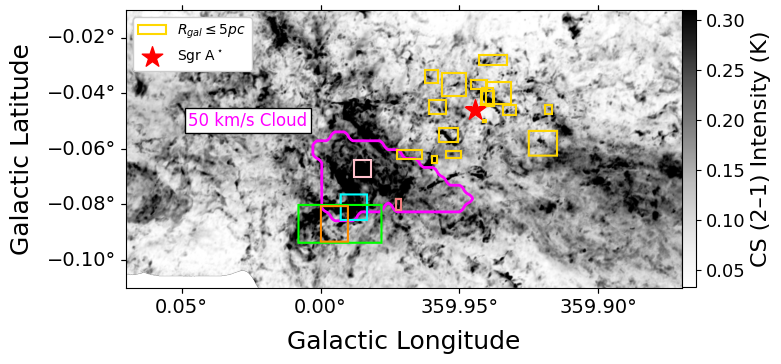

In [ ]:
# plotting
fig = plt.figure(figsize=(8, 6))
ax  = plt.subplot(projection=cutout_wcs)

# CS cutout
im = ax.imshow(cutout_data,origin='lower',cmap='Greys',vmin=np.nanpercentile(cs_max, 5),vmax=np.nanpercentile(cs_max, 99.5))

cs = ax.contour(mask_cut, levels=[0.5], colors='magenta',linewidths=2, zorder=1, label='50 km/s Cloud')
ax.annotate('50 km/s Cloud',xy=(0.05, -0.054),xycoords=ax.get_transform('galactic'),xytext=(5, 5), textcoords='offset points',color='magenta', fontsize=12, bbox=dict(boxstyle='square,pad=0.2',facecolor='white',edgecolor='black',linewidth=1))


# Sgr A* HVCCs

for idx in range(len(sgrA_5pc_hvdccs)):
    lc  = sgrA_5pc_hvdccs[idx]['l']
    bc  = sgrA_5pc_hvdccs[idx]['b']
    dl  = sgrA_5pc_hvdccs[idx]['deltal']
    db  = sgrA_5pc_hvdccs[idx]['deltab']

    if idx == 0:
        box = Rectangle((lc - dl/2, bc - db/2),
                        dl, db,
                        edgecolor='gold', facecolor='none',
                        linewidth=1.5,
                        transform=ax.get_transform('galactic'),
                        label= r'$R_{gal} \leq 5pc$')
        
        ax.add_patch(box)
    
    else:
        box = Rectangle((lc - dl/2, bc - db/2),
                        dl, db,
                        edgecolor='gold', facecolor='none',
                        linewidth=1.5,
                        transform=ax.get_transform('galactic'))
        
        ax.add_patch(box)

# 50 kms HVCCs

for idx, color in zip([37, 42, 40, 84, 36 ], ['aqua', 'pink', 'lightcoral','lime', 'darkorange']):
    lc  = tbl[idx]['l']
    bc  = tbl[idx]['b']
    dl  = tbl[idx]['deltal']
    db  = tbl[idx]['deltab']
    # box = Rectangle((lc - dl/2, bc - db/2),
    #                 dl, db,
    #                 edgecolor=color, facecolor='none',
    #                 linewidth=1.5,
    #                 transform=ax.get_transform('galactic'),
    #                 label=f'ID {idx}')
    box = Rectangle((lc - dl/2, bc - db/2),
                    dl, db,
                    edgecolor=color, facecolor='none',
                    linewidth=1.5,
                    transform=ax.get_transform('galactic'))
    
    ax.add_patch(box)


# Sgr A*
sgr = SkyCoord(l=359.94432*u.deg, b=-0.04619*u.deg,
               frame='galactic')
ax.scatter(sgr.l.deg, sgr.b.deg,
           transform=ax.get_transform('galactic'),
           s=240, marker='*', color='red', label = 'Sgr A$^\star$')

# ax.annotate('Sgr A*',
#             xy=(359.94, -0.04619),
#             xycoords=ax.get_transform('galactic'),
#             xytext=(5, 5), textcoords='offset points',
#             color='red', fontsize=12, bbox=dict(boxstyle='square,pad=0.2',
#                       facecolor='white',
#                       edgecolor='black',
#                       linewidth=1))


lon = ax.coords[0]
lat = ax.coords[1]
lon.set_major_formatter('d.dd')
lat.set_major_formatter('d.dd')
lon.set_ticklabel(size=14)
lat.set_ticklabel(size=14)

# Final label
ax.set_xlabel('Galactic Longitude', fontsize=18)
ax.set_ylabel('Galactic Latitude',  fontsize=18)
ax.set_aspect('equal')
ax.legend(loc='upper left', framealpha=1, fontsize=10)

cbar = plt.colorbar(im, ax=ax, pad=0.0, shrink = 0.55)
cbar.set_label('CS (2–1) Intensity (K)', fontsize=16)
cbar.ax.tick_params(labelsize=13)
plt.tight_layout()
plt.show()
#fig.savefig('50kms_evf.png', bbox_inches='tight', pad_inches=0.1)



# PA vs vel within central 60"?
Compare with Martin+2012 PA curves

In [5]:
#filters through table to determine all sources within 5pc of Sgr A*

gc_distance = 8.2 * u.kpc
length_pc = 5 * u.pc
length_deg = (length_pc / gc_distance).to(u.deg, equivalencies=u.dimensionless_angles())

length_deg = (50*u.arcsec).to(u.deg, equivalencies=u.arcsec)


sgrAstar_l = -0.0557
sgrAstar_b = -0.046
l_min = sgrAstar_l - length_deg.value
l_max = sgrAstar_l + length_deg.value
b_min = sgrAstar_b - length_deg.value
b_max = sgrAstar_b + length_deg.value

CND_hvdccs = tbl[(tbl['l'] >= l_min) & (tbl['l'] <= l_max) & (tbl['b'] >= b_min) &  (tbl['b'] <= b_max) ]


In [6]:
CND_hvdccs

ID Number,l,b,deltal,deltab,V_LSR,deltaV,Verticality,Size,Median Intensity,Spectrum FWHM,min_v,max_v,Classification Comments,dendro_match
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str55,float64
65,-0.046,-0.055,0.006944369625443869,0.005277730599327034,54.9262484,20.782904799999997,2992.771,0.9289859462836564,0.369,nan,50.4727688,71.2556736,associated with Sgr A* region - Oka+2012 classification,16004.0
67,-0.042,-0.045,0.00624993634215798,0.005277735188198171,106.8835104,20.78290480000001,3325.299,1.0141620151710316,0.193,nan,96.49205799999999,117.2749628,--,19831.0
68,-0.068,-0.046,0.004999932651458039,0.003611087020016543,-102.4300308,53.4417552,10688.495,0.5424899735870848,0.159,nan,-126.181922,-72.7401668,--,302.0
69,-0.06,-0.042,0.004861049844862464,0.005416626258524508,81.64712599999999,22.267398,4580.78,0.8148933025476152,0.295,nan,71.2556736,93.5230716,associated with Sgr A* region - Oka+2012 classification,17113.0
71,-0.059,-0.05,0.0008333230238122269,0.0009722171698720167,-41.565809599999994,16.329425199999996,19595.553,0.49344239920199234,0.211,nan,-48.988275599999994,-32.6588504,--,5200.0
72,-0.06,-0.041,0.003749952996201955,0.005833291779470014,81.64712599999999,29.689864,7917.396,0.6158847573237118,0.317,nan,69.7711804,99.4610444,associated with Sgr A* region - Oka+2012 classification,17113.0
80,-0.048,-0.037,0.008749900999873717,0.008194392662311763,96.49205799999999,51.957262,5938.04,0.8880093888932926,0.154,nan,56.410741599999994,108.3680036,--,15858.0
81,-0.057,-0.037,0.005833261558677805,0.003194417423236874,84.61611239999999,31.174357200000003,5344.241,0.7401635988029885,0.269,nan,74.22465999999999,105.39901719999999,--,17113.0
174,-0.064,-0.04,0.009166546260019004,0.008055507861646341,-35.6278368,50.47276879999999,1380.581,1.2638212333893557,0.143,nan,-44.53479599999999,5.9379728,nan,nan


In [7]:
np.degrees(np.arctan2(-0.034,-0.04))

np.float64(-139.63546342690265)

In [8]:
sga_coord=SkyCoord(sgrAstar_l*u.deg, sgrAstar_b*u.deg, frame="galactic", unit="deg")
sga_coord_celest = sga_coord.transform_to('fk5')

In [9]:
hvcc_coord_celest = SkyCoord(CND_hvdccs['l'][0]*u.deg, CND_hvdccs['b'][0]*u.deg, frame="galactic", unit="deg").transform_to('fk5')
hvcc_coord_celest
SkyCoord(ra=hvcc_coord_celest.ra,dec=hvcc_coord_celest.dec, frame='fk5').to_string('hmsdms')

'17h45m43.5044245s -29d00m14.7212835s'

In [10]:
hvcc_coord_celest_list = SkyCoord(CND_hvdccs['l']*u.deg, CND_hvdccs['b']*u.deg, frame="galactic", unit="deg").transform_to('fk5')
hvcc_coord_celest_list

<SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    [(266.43126844, -29.00408925), (266.42389048, -28.99546603),
     (266.40937924, -29.01818031), (266.41024111, -29.00926786),
     (266.4186452 , -29.01258196), (266.40926511, -29.00874686),
     (266.41250955, -28.99642014), (266.40714841, -29.00410218),
     (266.40590607, -29.01164005)]>

In [11]:
hvcc_PA_list = np.array((90-np.degrees(np.arctan2((hvcc_coord_celest_list.dec.value-sga_coord_celest.dec.value),(hvcc_coord_celest_list.ra.value-sga_coord_celest.ra.value))) )% 360)
hvcc_vel_list = CND_hvdccs['V_LSR']
hvcc_id_list = CND_hvdccs['ID Number']

In [ ]:
def v_obs(i,theta):
    #for circular orbit, eccentricity=0
    G = 6.67e-11 #kgs units
    M = 1e4 * 1.989e33 #enclosed mass kgs units
    mu = G*M
    a = (3 * u.pc).to(u.m).value




    return (np.sqrt(mu/a)*np.sin(np.radians(i))*np.cos(np.radians(theta)))/1e3 # km/s #This is total vel, not LOS vel????


##The following code for PA-velocity diagrams was borrowed and adapted from Dr. Elisabeth Mills ##

#this function defines a rotation curve for uniform circular rotation 
#returens the (radial) rotational velocity as a function of input angle
def rotfunction(ang,off=30,inc=80,vrot=120): 
    cos_angoff = np.cos((ang-off)*np.pi/180.0)
    sin_angoff = np.sin((ang-off)*np.pi/180.0)
    cosinc = np.cos(inc * np.pi / 180.0)
    return vrot * np.sin(inc* np.pi / 180.0) * cos_angoff / np.sqrt(cos_angoff**2 + sin_angoff**2/cosinc**2)

#these two functions define a parametric equation for an ellipse
#used for overplotting elliptical rings on maps of the data, for example
def ellipse_x(rad,inc,ang,tilt=300): #not sure how angle of 300 is defined.
    a = rad
    b = rad * np.cos(inc*np.pi/180.0)
    tilt = tilt*np.pi/180.0
    return a * np.cos(ang)*np.cos(tilt) - b * np.sin(ang)*np.sin(tilt)
def ellipse_y(rad,inc,ang,tilt=300):
    a = rad
    b = rad * np.cos(inc*np.pi/180.0)
    tilt = tilt*np.pi/180.0
    return b * np.cos(tilt)*np.sin(ang) + a * np.sin(tilt)*np.cos(ang)

#this function determines if an x,y pixel is within an ellipse with radius=rad, inclination=inc
#returns a boolean value
def ellipse_where(rad,inc,x,y,tilt=300): 
    a = rad
    b = rad * np.cos(inc*np.pi/180.0)
    tilt = tilt*np.pi/180.0
    return ((x*np.cos(tilt)+y*np.sin(tilt))**2/a**2 +(x*np.sin(tilt)-y*np.cos(tilt))**2/b**2 <1)

#axis order: frequency, y, x for a native CASA image cube. 
#There is also usuall a Stokes (polarization) axis that we call 'degenerate'-- has a length of 1


PA_arr = np.linspace(0,360,150)

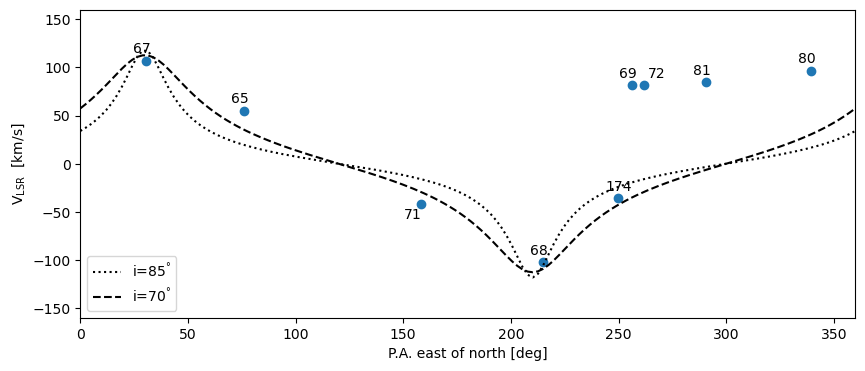

In [13]:
plt.figure(figsize=(10,4))
ax = plt.subplot()
ax.scatter(hvcc_PA_list,hvcc_vel_list)
ax.plot(PA_arr,rotfunction(PA_arr,inc=80),linestyle=':',label=r'i=85$^{\degree}$',color='k')
ax.plot(PA_arr,rotfunction(PA_arr,inc=70),linestyle='--',label=r'i=70$^{\degree}$',color='k')

for i in range(len(hvcc_id_list)):
    if hvcc_id_list[i] == 71:
        ax.text(hvcc_PA_list[i]-8, hvcc_vel_list[i]-16,s=hvcc_id_list[i],color='k')
    elif hvcc_id_list[i] == 72:
        ax.text(hvcc_PA_list[i]+2, hvcc_vel_list[i]+8,s=hvcc_id_list[i],color='k')
    else:
        ax.text(hvcc_PA_list[i]-6, hvcc_vel_list[i]+8,s=hvcc_id_list[i],color='k')

           

ax.set_xlim(0,360)
ax.set_ylim(-160,160)

ax.set_xlabel("P.A. east of north [deg]")
ax.set_ylabel(r"V$_{\rm{LSR}}~~$[km/s]")

ax.legend()

#ax.hlines(80,250,360)

In [93]:
##Create cutout for use in Betsy's code for PA-vel map

CND_PA_reg = Regions.read('CND_region_PA', format='ds9')


def read_cube_slab(filename):


    cube = SpectralCube.read(filename)
    #convert to frequency units
    cube_u = cube.with_spectral_unit(u.km/u.s,
                            velocity_convention='radio',
                            rest_value=cube.header['RESTFRQ']*u.Hz)
    
    subcube = cube_u.subcube_from_regions(CND_PA_reg)
    

    #pull out spectral slab 

    return subcube 



CS_cube = read_cube_slab("../../Farhad/DATA/ACES_icrs.12m7mTP.CS21.cube.pbcor_cutout.fits")
HC3N_cube = read_cube_slab("../../Farhad/DATA/ACES_icrs.12m7mTP.HC3N.cube.pbcor_cutout.fits")

CS_cube.write('./CS_CND_cutout.fits',format='fits',overwrite=True)
HC3N_cube.write('./HC3N_CND_cutout.fits',format='fits',overwrite=True)


In [ ]:
import pylab
CS_cube = pylab.squeeze(fits.getdata('CS_CND_cutout.fits'))
HC3N_cube = pylab.squeeze(fits.getdata('HC3N_CND_cutout.fits'))

#pixel coordinates of the black hole in these images
#note that this is all just for the Band 6 data. 
#Would need to reshape other data (Band 3 or Band 7) to be the same size
sgrastar_x = 109 
sgrastar_y = 125

z = np.arange(0,233)
z_y = np.reshape(z,(1,233))
x = np.tile(z,(233,1)) #make pixel index arrays
y = np.rot90(x,3)

zero_x = x - sgrastar_x #center the pixel indices on the black hole
zero_y = y - sgrastar_y

theta = np.arctan2(zero_y,zero_x) #define a new coordinate theta
theta = (theta + np.pi)*180.0/np.pi
r = np.sqrt(zero_x**2 + zero_y**2) #define a new coordinate r

whereplus = pylab.where(theta<270)
whereminus = pylab.where(theta >= 270)

theta[whereplus] = theta[whereplus] + 90 #Tweak theta to match the astronomical norm (defined as east of north)
theta[whereminus] = theta[whereminus] - 270

#Make a set of ellipses to use for masking the data
#Use a default inclination of 60 degrees which is a by-eye fit to the inclination of the CND in these data 
e0 = ellipse_where(25,60,zero_x,zero_y)
e1 = ellipse_where(50,60,zero_x,zero_y)
e2 = ellipse_where(75,60,zero_x,zero_y)
e3 = ellipse_where(100,60,zero_x,zero_y)
e4 = ellipse_where(140,60,zero_x,zero_y)

#ring_e = pylab.where((small_e==False)*(big_e==True))
ring0 = pylab.where((e0==True)+(e1==False))
ring1 = pylab.where((e1==True)+(e2==False))
ring2 = pylab.where((e2==True)+(e3==False))
ring3 = pylab.where((e3==True)+(e4==False))


def get_PA_map(cube):

        
        cube_shape = np.shape(cube)
        cubecopy = cube.copy()

        max_pos_ang = np.zeros((360,cube_shape[0]))
        int_pos_ang = np.zeros((360,cube_shape[0]))

        for i in np.arange(0,360):
                wherex = x[pylab.where((theta>i)*(theta<i+1))]
                wherey = y[pylab.where((theta>i)*(theta<i+1))]
                int_pos_ang[i,:] = np.nansum(cube[:,wherey, wherex],axis=1) #taking the sum in bins of position angle for every radius
                max_pos_ang[i,:] = np.nanmax(cube[:,wherey, wherex],axis=1) #taking maximum instead, again over all radii at an angle

        max_pos_ang = np.rot90(max_pos_ang)
        int_pos_ang = np.rot90(int_pos_ang)

        return  int_pos_ang,max_pos_ang


In [104]:
CSint_pos_ang,CSmax_pos_ang = get_PA_map(CS_cube)
HC3Nint_pos_ang,HC3Nmax_pos_ang = get_PA_map(HC3N_cube)

In [119]:
CS_spec_cube = SpectralCube.read('CS_CND_cutout.fits')
#convert to frequency units
CS_spec_cube = CS_spec_cube.with_spectral_unit(u.km/u.s,
                        velocity_convention='radio',
                        rest_value=CS_spec_cube.header['RESTFRQ']*u.Hz)
CSmom0 = CS_spec_cube.moment(axis=0)


Text(0.8, 0.1, 'E')

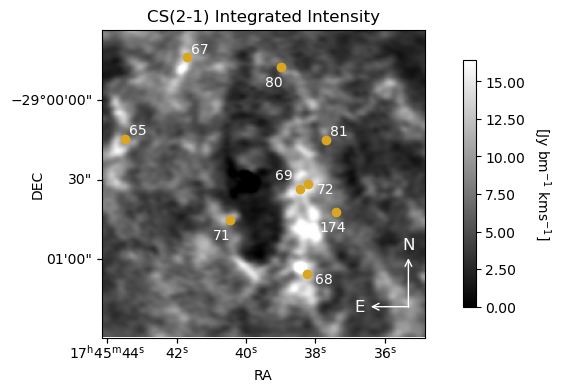

In [208]:
#plot RA-DEC
fig =plt.figure(figsize=(10,4))
ax = plt.subplot(projection=CS_spec_cube.wcs.celestial)

vmax_99 = np.nanpercentile(CS_spec_cube.moment(axis=0).value, 99.5)
cmap=plt.get_cmap('gist_gray')
cmap.set_under('black')
im_radec = ax.imshow(CS_spec_cube.moment(axis=0).value,cmap=cmap, norm=colors.Normalize(vmin=0., vmax=vmax_99))

for i in range(len(hvcc_coord_celest_list)):
    ax.scatter(hvcc_coord_celest_list[i].ra,hvcc_coord_celest_list[i].dec,c='goldenrod',transform=ax.get_transform('fk5'))


for i in range(len(hvcc_id_list)):
    if hvcc_id_list[i] == 68:
        ax.text(hvcc_coord_celest_list[i].ra.value-.001,hvcc_coord_celest_list[i].dec.value-0.001,s=hvcc_id_list[i],color='white',zorder=10,transform=ax.get_transform('fk5'))
    elif hvcc_id_list[i] == 72:
        ax.text(hvcc_coord_celest_list[i].ra.value-.001,hvcc_coord_celest_list[i].dec.value-0.001,s=hvcc_id_list[i],color='white',zorder=10,transform=ax.get_transform('fk5'))
    elif hvcc_id_list[i] == 69:
            ax.text(hvcc_coord_celest_list[i].ra.value+.003,hvcc_coord_celest_list[i].dec.value+0.001,s=hvcc_id_list[i],color='white',zorder=10,transform=ax.get_transform('fk5'))
    elif hvcc_id_list[i] == 65:
                ax.text(hvcc_coord_celest_list[i].ra.value-.0005,hvcc_coord_celest_list[i].dec.value+0.0005,s=hvcc_id_list[i],color='white',zorder=10,transform=ax.get_transform('fk5'))
    elif hvcc_id_list[i] == 81:
                    ax.text(hvcc_coord_celest_list[i].ra.value-.0005,hvcc_coord_celest_list[i].dec.value+0.0005,s=hvcc_id_list[i],color='white',zorder=10,transform=ax.get_transform('fk5'))
            
    elif hvcc_id_list[i] == 67:
                    ax.text(hvcc_coord_celest_list[i].ra.value-.0005,hvcc_coord_celest_list[i].dec.value+0.0005,s=hvcc_id_list[i],color='white',zorder=10,transform=ax.get_transform('fk5'))
            
        
    

    else:
        ax.text(hvcc_coord_celest_list[i].ra.value+.002,hvcc_coord_celest_list[i].dec.value-0.002,s=hvcc_id_list[i],color='white',zorder=10,transform=ax.get_transform('fk5'))


cb_radec = fig.colorbar(im_radec, ax=ax,shrink=0.8,format='{x:.2f}')
cb_radec.set_label(r'[Jy bm$^{-1}$ kms$^{-1}$]', rotation=270, labelpad=20)



ax.set_ylabel("DEC",labelpad=-2)
ax.set_xlabel("RA")

ra = ax.coords[0]
dec = ax.coords[1]
ra.set_ticks_position('b')
ra.set_ticklabel_position('b')
ra.set_axislabel_position('b')
dec.set_ticks_position('l')
dec.set_ticklabel_position('l')
dec.set_axislabel_position('l')


ax.set_title('CS(2-1) Integrated Intensity')

#scalebar = add_scalebar(ax, 1 * u.arcmin, label=r'1$^\prime$', corner='bottom left',color='white')

ax.annotate('N', xy=(0.95, .09), xytext=(0.95, 0.3),
            arrowprops=dict(arrowstyle="<-",facecolor='white',edgecolor='white'),
            ha='center', va='center', fontsize=12,
            xycoords='axes fraction',c='white')
ax.annotate('E', xy=(0.96, .1), xytext=(0.8, .1),
            arrowprops=dict(arrowstyle="<-",facecolor='white',edgecolor='white'),
            ha='center', va='center', fontsize=12,
            xycoords='axes fraction',c='white')

Text(0.5, 1.0, 'CS(2-1) Integrated Intensity')

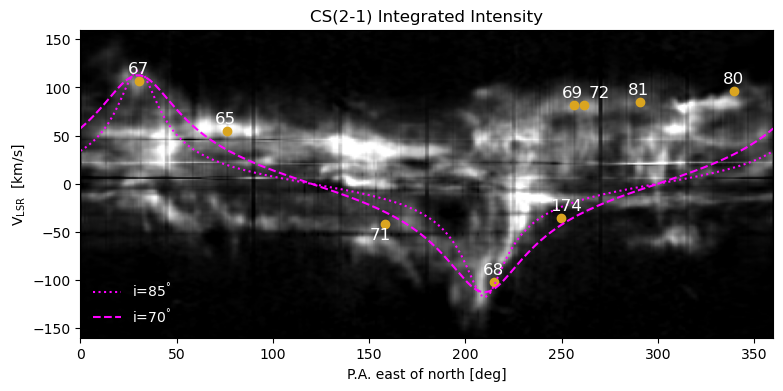

In [209]:
plt.figure(figsize=(10,4))
ax = plt.subplot()
ax.imshow(np.flipud(CSint_pos_ang),extent=[0,360,-258,260],cmap='gist_gray',norm=colors.Normalize(vmin=0., vmax=vmax_99))
ax.scatter(hvcc_PA_list,hvcc_vel_list,c='goldenrod')
ax.plot(PA_arr,rotfunction(PA_arr,inc=80),linestyle=':',label=r'i=85$^{\degree}$',color='magenta')
ax.plot(PA_arr,rotfunction(PA_arr,inc=70),linestyle='--',label=r'i=70$^{\degree}$',color='magenta')

fontsize=12
for i in range(len(hvcc_id_list)):
    if hvcc_id_list[i] == 71:
        ax.text(hvcc_PA_list[i]-8, hvcc_vel_list[i]-16,s=hvcc_id_list[i],color='white',fontsize=fontsize)
    elif hvcc_id_list[i] == 72:
        ax.text(hvcc_PA_list[i]+2, hvcc_vel_list[i]+8,s=hvcc_id_list[i],color='white',fontsize=fontsize)
    else:
        ax.text(hvcc_PA_list[i]-6, hvcc_vel_list[i]+8,s=hvcc_id_list[i],color='white',fontsize=fontsize)

           

ax.set_xlim(0,360)
ax.set_ylim(-160,160)

ax.set_xlabel("P.A. east of north [deg]")
ax.set_ylabel(r"V$_{\rm{LSR}}~~$[km/s]")
ax.set_aspect(0.5)
ax.legend(frameon=False,labelcolor='white')

ax.set_title('CS(2-1) Integrated Intensity')